# Fairness Analysis

With the labels predicted in the test sample of the predictive analysis, the **Aequitas** toolkit is used to assess the fairness of the model's predictions across different demographic and health-related groups.

Fairness analysis helps identify whether a predictive model performs differently for certain groups of individuals, which could lead to biased outcomes.

In this section we:
- Prepare the dataset for fairness evaluation
- Compute fairness metrics using Aequitas
- Compare disparities across different demographic and health attributes
- Visualize disparities using tree maps

In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

import aequitas as aq
from aequitas.plotting import Plot
from aequitas.group import Group
from aequitas.bias import Bias
from aequitas.fairness import Fairness
import aequitas.plot as ap

In [123]:
diab_df = pd.read_csv('/Users/louisbarthelemy/Library/Mobile Documents/com~apple~CloudDocs/Mines Paris/3A/cookiecutter-data-science/Diabetes_prediction/data/diabetes_with_predicted_labels.csv')
diab_df.head()

,Unnamed: 0,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,CholxCheck,BMIxChol,IncomexAge,BPxAge,BPxChol,AgexBMI,AgexGenHlth,label_value,score,BMI_categorical
0,172554,0.0,0.0,1.0,1.0,26.0,0.0,0.0,0.0,1.0,...,1.0,26.0,0.500000,0.0,0.0,104.0,4.0,0.0,0.0,Overweight
1,105742,2.0,1.0,1.0,1.0,16.0,0.0,0.0,1.0,1.0,...,1.0,16.0,1.714286,12.0,1.0,192.0,36.0,1.0,1.0,Underweight
2,149087,2.0,1.0,1.0,1.0,26.0,1.0,0.0,1.0,0.0,...,1.0,26.0,1.571429,11.0,1.0,286.0,55.0,1.0,1.0,Overweight
3,145979,0.0,0.0,0.0,1.0,31.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.875000,0.0,0.0,217.0,14.0,0.0,0.0,Obesity Class I
4,239661,2.0,1.0,1.0,1.0,42.0,1.0,0.0,1.0,0.0,...,1.0,42.0,5.000000,5.0,1.0,210.0,20.0,1.0,1.0,Severe Obesity


In [124]:
diab_df["BPxChol"] = diab_df["HighBP"] * diab_df["HighChol"]

diab_df = diab_df[["BPxChol", "Age", "GenHlth", "BMI", "Income", "Diabetes_012"]]

diab_df["Diabetes_012"] = diab_df["Diabetes_012"].replace(2, 1)

features = ["BPxChol", "Age", "GenHlth", "BMI"]

diab_model_df = diab_df[["Diabetes_012"] + features]

X = diab_model_df.loc[diab_model_df["Diabetes_012"], :].drop(columns=["Diabetes_012"])
y = diab_model_df.loc[diab_model_df["Diabetes_012"], "Diabetes_012"]

undersampler = RandomUnderSampler()

X_resampled, y_resampled = undersampler.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2
)

scaler = MinMaxScaler()

X_train_sc = scaler.fit_transform(X_train[features])
X_test_sc = scaler.transform(X_test[features])

In [125]:
model = RandomForestClassifier(
    criterion="gini",
    max_features='sqrt',
    max_leaf_nodes=16,
    max_depth=6,
    n_estimators=100
)

In [126]:
# assess model performance with cross-validation
scoring = ['accuracy', 'f1_macro']
scores = cross_validate(model, X_train_sc, y_train, cv=5, scoring=scoring)

# train the model
model.fit(X_train_sc, y_train)

# predict on test set
y_pred = model.predict(X_test_sc)

## Fairness Preprocessing

Some variables contain many categories that make fairness analysis difficult to interpret.  
To simplify the analysis:

- **Age** is grouped into bins
- **Income** is grouped into broader ranges

This allows the fairness metrics to be evaluated across meaningful demographic groups.

## Feature Selection

Only the features relevant for fairness analysis are kept in the dataset:

- Prediction score
- True label
- Age
- BMI category
- Blood Pressure × Cholesterol
- General Health
- Income

In [127]:
y_pred.shape

(2804,)

In [128]:
df = diab_df.copy()[-len(y_pred):]
df["score"] = y_pred
df = df.rename(columns={"Diabetes_012" : "label_value"})
df["Income"] = diab_df["Income"][-df.shape[0]:]

In [129]:
diab_df["Income"]

0        8.0
1        7.0
2        7.0
3        8.0
4        1.0
        ... 
14134    3.0
14135    7.0
14136    6.0
14137    7.0
14138    7.0
Name: Income, Length: 14139, dtype: float64

In [130]:
df.head(
)

,BPxChol,Age,GenHlth,BMI,Income,label_value,score
11335,1.0,11.0,3.0,26.0,1.0,0.0,1.0
11336,0.0,2.0,2.0,24.0,8.0,0.0,0.0
11337,1.0,9.0,2.0,33.0,8.0,1.0,1.0
11338,1.0,11.0,3.0,36.0,5.0,1.0,0.0
11339,0.0,7.0,2.0,50.0,6.0,0.0,1.0


In [131]:
# Data Preprocessing to have less categories
df['Age'] = pd.cut(df['Age'], bins=[0, 2, 4, 6, 8, 10, 13], 
                   labels=['0-2', '2-4', '4-6', '6-8', '8-10', '10-13'])

df['Income'] = pd.cut(df['Income'], bins=[1, 3, 5, 6, 8], 
                      labels=['1-2', '3-4', '5-6', '7-8'], include_lowest=True)

df['BMI_categorical'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 35, 40, 100], 
                                     labels=["Underweight", "Healthy", "Overweight", "Obesity Class I",
          "Obesity Class II", "Severe Obesity"], include_lowest=True)

In [132]:
# Selection of the features used in the predictive analysis
df = df[['score', 'label_value', 'Age', 'BMI_categorical', 
         'BPxChol', 'GenHlth', 'Income']]

## Data Type Formatting

Aequitas requires categorical attributes to be stored as **string values**.  
Therefore, all categorical columns are converted to strings while prediction score and labels remain numerical.

In [133]:
# Convert categorical columns to string
non_string_cols = df.columns[(df.dtypes != object) & (df.dtypes != str)]
df[non_string_cols] = df[non_string_cols].astype(str)

df['score'] = df['score'].astype(float)
df['label_value'] = df['label_value'].astype(float)

## Group Metrics Calculation

Aequitas first computes **group-level performance metrics** using cross-tabulations.

These metrics include:
- Precision
- Recall
- False positive rate
- True positive rate

The metrics are calculated separately for each value of each attribute.

In [134]:
group = Group()
xtab, _ = group.get_crosstabs(df)

absolute_metrics = group.list_absolute_metrics(xtab)

xtab[['attribute_name', 'attribute_value'] + absolute_metrics].round(2)

,attribute_name,attribute_value,tpr,tnr,for,fdr,fpr,fnr,npv,precision,ppr,pprev,prev
0,Age,0-2,0.33,0.52,0.06,0.96,0.48,0.67,0.94,0.04,0.04,0.47,0.05
1,Age,10-13,0.51,0.49,0.61,0.38,0.51,0.49,0.39,0.62,0.26,0.51,0.61
2,Age,2-4,0.59,0.54,0.12,0.82,0.46,0.41,0.88,0.18,0.07,0.48,0.15
3,Age,4-6,0.43,0.48,0.38,0.70,0.52,0.57,0.62,0.30,0.11,0.49,0.34
4,Age,6-8,0.50,0.50,0.47,0.54,0.50,0.50,0.53,0.46,0.21,0.50,0.47
5,Age,8-10,0.53,0.50,0.57,0.41,0.50,0.47,0.43,0.59,0.31,0.52,0.58
6,BMI_categorical,Healthy,0.48,0.51,0.29,0.73,0.49,0.52,0.71,0.27,0.26,0.49,0.28
7,BMI_categorical,Obesity Class I,0.51,0.48,0.60,0.41,0.52,0.49,0.40,0.59,0.23,0.51,0.60
8,BMI_categorical,Obesity Class II,0.55,0.52,0.73,0.21,0.48,0.45,0.27,0.79,0.10,0.53,0.76
9,BMI_categorical,Overweight,0.51,0.51,0.44,0.54,0.49,0.49,0.56,0.46,0.33,0.50,0.45


## Bias and Disparity Analysis

Disparity metrics measure how different a group’s performance is compared to a **reference group**.

In this analysis, the reference group represents **healthy individuals with average demographic characteristics** within the dataset.

Reference group characteristics:

- **Age:** `6–8` (approximately 45–54 years old)
- **BMI:** `Healthy`
- **Blood Pressure × Cholesterol:** `0.0`
- **General Health:** `2.0` (out of 5 bins)
- **Income:** `3–4` (approximately \$20,000–\$25,000 yearly)

Disparity coefficients equal **1** for the reference group because all other groups are compared against it.

In [135]:
bias = Bias()

bias_df = bias.get_disparity_predefined_groups(
    xtab,
    original_df=df,
    ref_groups_dict={
        'Age': '6-8',
        'BMI_categorical': 'Healthy',
        'BPxChol': '0.0',
        'GenHlth': '2.0',
        'Income': '3-4'
    },
    alpha=0.05,
    check_significance=True,
    mask_significance=True
)

bias_df.style

get_disparity_predefined_group()


/Users/louisbarthelemy/Library/Mobile Documents/com~apple~CloudDocs/Mines Paris/3A/cookiecutter-data-science/Diabetes_prediction/diabetes/lib/python3.12/site-packages/scipy/stats/_morestats.py:3345: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom
/Users/louisbarthelemy/Library/Mobile Documents/com~apple~CloudDocs/Mines Paris/3A/cookiecutter-data-science/Diabetes_prediction/diabetes/lib/python3.12/site-packages/scipy/stats/_morestats.py:3345: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom
/Users/louisbarthelemy/Library/Mobile Documents/com~apple~CloudDocs/Mines Paris/3A/cookiecutter-data-science/Diabetes_prediction/diabetes/lib/python3.12/site-packages/scipy/stats/_morestats.py:3345: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom
/Users/louisbarthelemy/Library/Mobile Documents/com~apple~CloudDocs/Mines Paris/3A/cookiecutter-data-science/Diabetes_prediction/diabetes/lib/python3.12/site-packages

,model_id,score_threshold,k,attribute_name,attribute_value,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev,label_value_significance,score_significance,fdr_disparity,fdr_ref_group_value,fdr_significance,fnr_disparity,fnr_ref_group_value,fnr_significance,for_disparity,for_ref_group_value,for_significance,fpr_disparity,fpr_ref_group_value,fpr_significance,npv_disparity,npv_ref_group_value,npv_significance,ppr_disparity,ppr_ref_group_value,ppr_significance,pprev_disparity,pprev_ref_group_value,pprev_significance,precision_disparity,precision_ref_group_value,precision_significance,tnr_disparity,tnr_ref_group_value,tnr_significance,tpr_disparity,tpr_ref_group_value,tpr_significance
0,0,binary 0/1,1409,Age,0-2,0.333333,0.517857,0.064516,0.964286,0.482143,0.666667,0.935484,0.035714,56,62,0.039744,0.474576,54,4,58,2,6,112,118,2804,0.050847,True,False,1.797619,6-8,True,1.323944,6-8,True,0.137210,6-8,True,0.958333,6-8,True,1.765726,6-8,True,0.185430,6-8,False,0.949153,6-8,False,0.077041,6-8,True,1.042188,6-8,True,0.671429,6-8,True
1,0,binary 0/1,1409,Age,10-13,0.507937,0.494585,0.612994,0.384615,0.505415,0.492063,0.387006,0.615385,364,354,0.258339,0.506964,140,217,137,224,441,277,718,2804,0.614206,True,False,0.716999,6-8,True,0.977197,6-8,True,1.303692,6-8,True,1.004591,6-8,True,0.730473,6-8,True,1.205298,6-8,False,1.013928,6-8,False,1.327473,6-8,True,0.995352,6-8,True,1.023129,6-8,True
2,0,binary 0/1,1409,Age,2-4,0.586207,0.541176,0.115385,0.821053,0.458824,0.413793,0.884615,0.178947,95,104,0.067424,0.477387,78,12,92,17,29,170,199,2804,0.145729,True,False,1.530604,6-8,True,0.821758,6-8,True,0.245395,6-8,True,0.911983,6-8,True,1.669712,6-8,True,0.314570,6-8,False,0.954774,6-8,False,0.386015,6-8,True,1.089118,6-8,True,1.180788,6-8,True
3,0,binary 0/1,1409,Age,4-6,0.428571,0.479263,0.380952,0.701863,0.520737,0.571429,0.619048,0.298137,161,168,0.114265,0.489362,113,64,104,48,112,217,329,2804,0.340426,True,False,1.308412,6-8,True,1.134809,6-8,False,0.810195,6-8,False,1.035046,6-8,True,1.168452,6-8,False,0.533113,6-8,False,0.978723,6-8,False,0.643123,6-8,True,0.964516,6-8,True,0.863265,6-8,False
4,0,binary 0/1,1409,Age,6-8,0.496454,0.496894,0.470199,0.536424,0.503106,0.503546,0.529801,0.463576,302,302,0.214336,0.500000,162,142,160,140,282,322,604,2804,0.466887,False,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False
5,0,binary 0/1,1409,Age,8-10,0.525667,0.498567,0.570370,0.406032,0.501433,0.474333,0.429630,0.593968,431,405,0.305891,0.515550,175,231,174,256,487,349,836,2804,0.582536,True,False,0.756925,6-8,True,0.941985,6-8,True,1.213041,6-8,True,0.996675,6-8,True,0.810926,6-8,True,1.427152,6-8,False,1.031100,6-8,False,1.281273,6-8,True,1.003367,6-8,True,1.058844,6-8,True
6,0,binary 0/1,1409,BMI_categorical,Healthy,0.478873,0.506399,0.286082,0.725806,0.493601,0.521127,0.713918,0.274194,372,388,0.264017,0.489474,270,111,277,102,213,547,760,2804,0.280263,False,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False
7,0,binary 0/1,1409,BMI_categorical,Obesity Class I,0.511811,0.480620,0.600000,0.407295,0.519380,0.488189,0.400000,0.592705,329,310,0.233499,0.514867,134,186,124,195,381,258,639,2804,0.596244,True,False,0.561162,Healthy,True,0.936795,Healthy,True,2.097297,Healthy,True,1.052225,Healthy,True,0.560289,Healthy,True,0.884409,Healthy,False,1.051879,Healthy,False,2.161631,Healthy,True,0.949095,Healthy,True,1.068782,Healthy,True
8,0,binary 0/1,1409,BMI_categorical,Obesity Class II,0.549223,0.524590,0.731092,0.214815,0.475410,0.450777,0.268908,0.785185,135,119,0.095813,0.531496,29,87,32,106,193,61,254,2804,0.759843,True,False,0.295967,Healthy,Tr

## Disparity Metrics Overview

The following table shows disparity metrics and their statistical significance.

These values indicate how far each group's prediction performance deviates from the reference group.

In [136]:
bias_df[['attribute_name', 'attribute_value'] +
        bias.list_disparities(bias_df) +
        bias.list_significance(bias_df)].style

,attribute_name,attribute_value,fdr_disparity,fnr_disparity,for_disparity,fpr_disparity,npv_disparity,ppr_disparity,pprev_disparity,precision_disparity,tnr_disparity,tpr_disparity,label_value_significance,score_significance,fdr_significance,fnr_significance,for_significance,fpr_significance,npv_significance,ppr_significance,pprev_significance,precision_significance,tnr_significance,tpr_significance
0,Age,0-2,1.797619,1.323944,0.137210,0.958333,1.765726,0.185430,0.949153,0.077041,1.042188,0.671429,True,False,True,True,True,True,True,False,False,True,True,True
1,Age,10-13,0.716999,0.977197,1.303692,1.004591,0.730473,1.205298,1.013928,1.327473,0.995352,1.023129,True,False,True,True,True,True,True,False,False,True,True,True
2,Age,2-4,1.530604,0.821758,0.245395,0.911983,1.669712,0.314570,0.954774,0.386015,1.089118,1.180788,True,False,True,True,True,True,True,False,False,True,True,True
3,Age,4-6,1.308412,1.134809,0.810195,1.035046,1.168452,0.533113,0.978723,0.643123,0.964516,0.863265,True,False,True,False,False,True,False,False,False,True,True,False
4,Age,6-8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,False,False,False,False,False,False,False,False,False,False,False,False
5,Age,8-10,0.756925,0.941985,1.213041,0.996675,0.810926,1.427152,1.031100,1.281273,1.003367,1.058844,True,False,True,True,True,True,True,False,False,True,True,True
6,BMI_categorical,Healthy,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,False,False,False,False,False,False,False,False,False,False,False,False
7,BMI_categorical,Obesity Class I,0.561162,0.936795,2.097297,1.052225,0.560289,0.884409,1.051879,2.161631,0.949095,1.068782,True,False,True,True,True,True,True,False,False,True,True,True
8,BMI_categorical,Obesity Class II,0.295967,0.865005,2.555530,0.963145,0.376665,0.362903,1.085852,2.863617,1.035924,1.146906,True,False,True,True,True,True,True,False,False,True,True,True
9,BMI_categorical,Overweight,0.741431,0.934626,1.539505,0.995329,0.783808,1.268817,1.023674,1.684447,1.004553,1.071142,True,False,True,True,True,True,True,False,False,True,True,True


## Precision Disparities

The visualization below displays **precision disparities** across feature groups.

Each square in the tree map:
- Represents a demographic group
- Has an area proportional to its population size
- Uses color to indicate disparity magnitude relative to the reference group

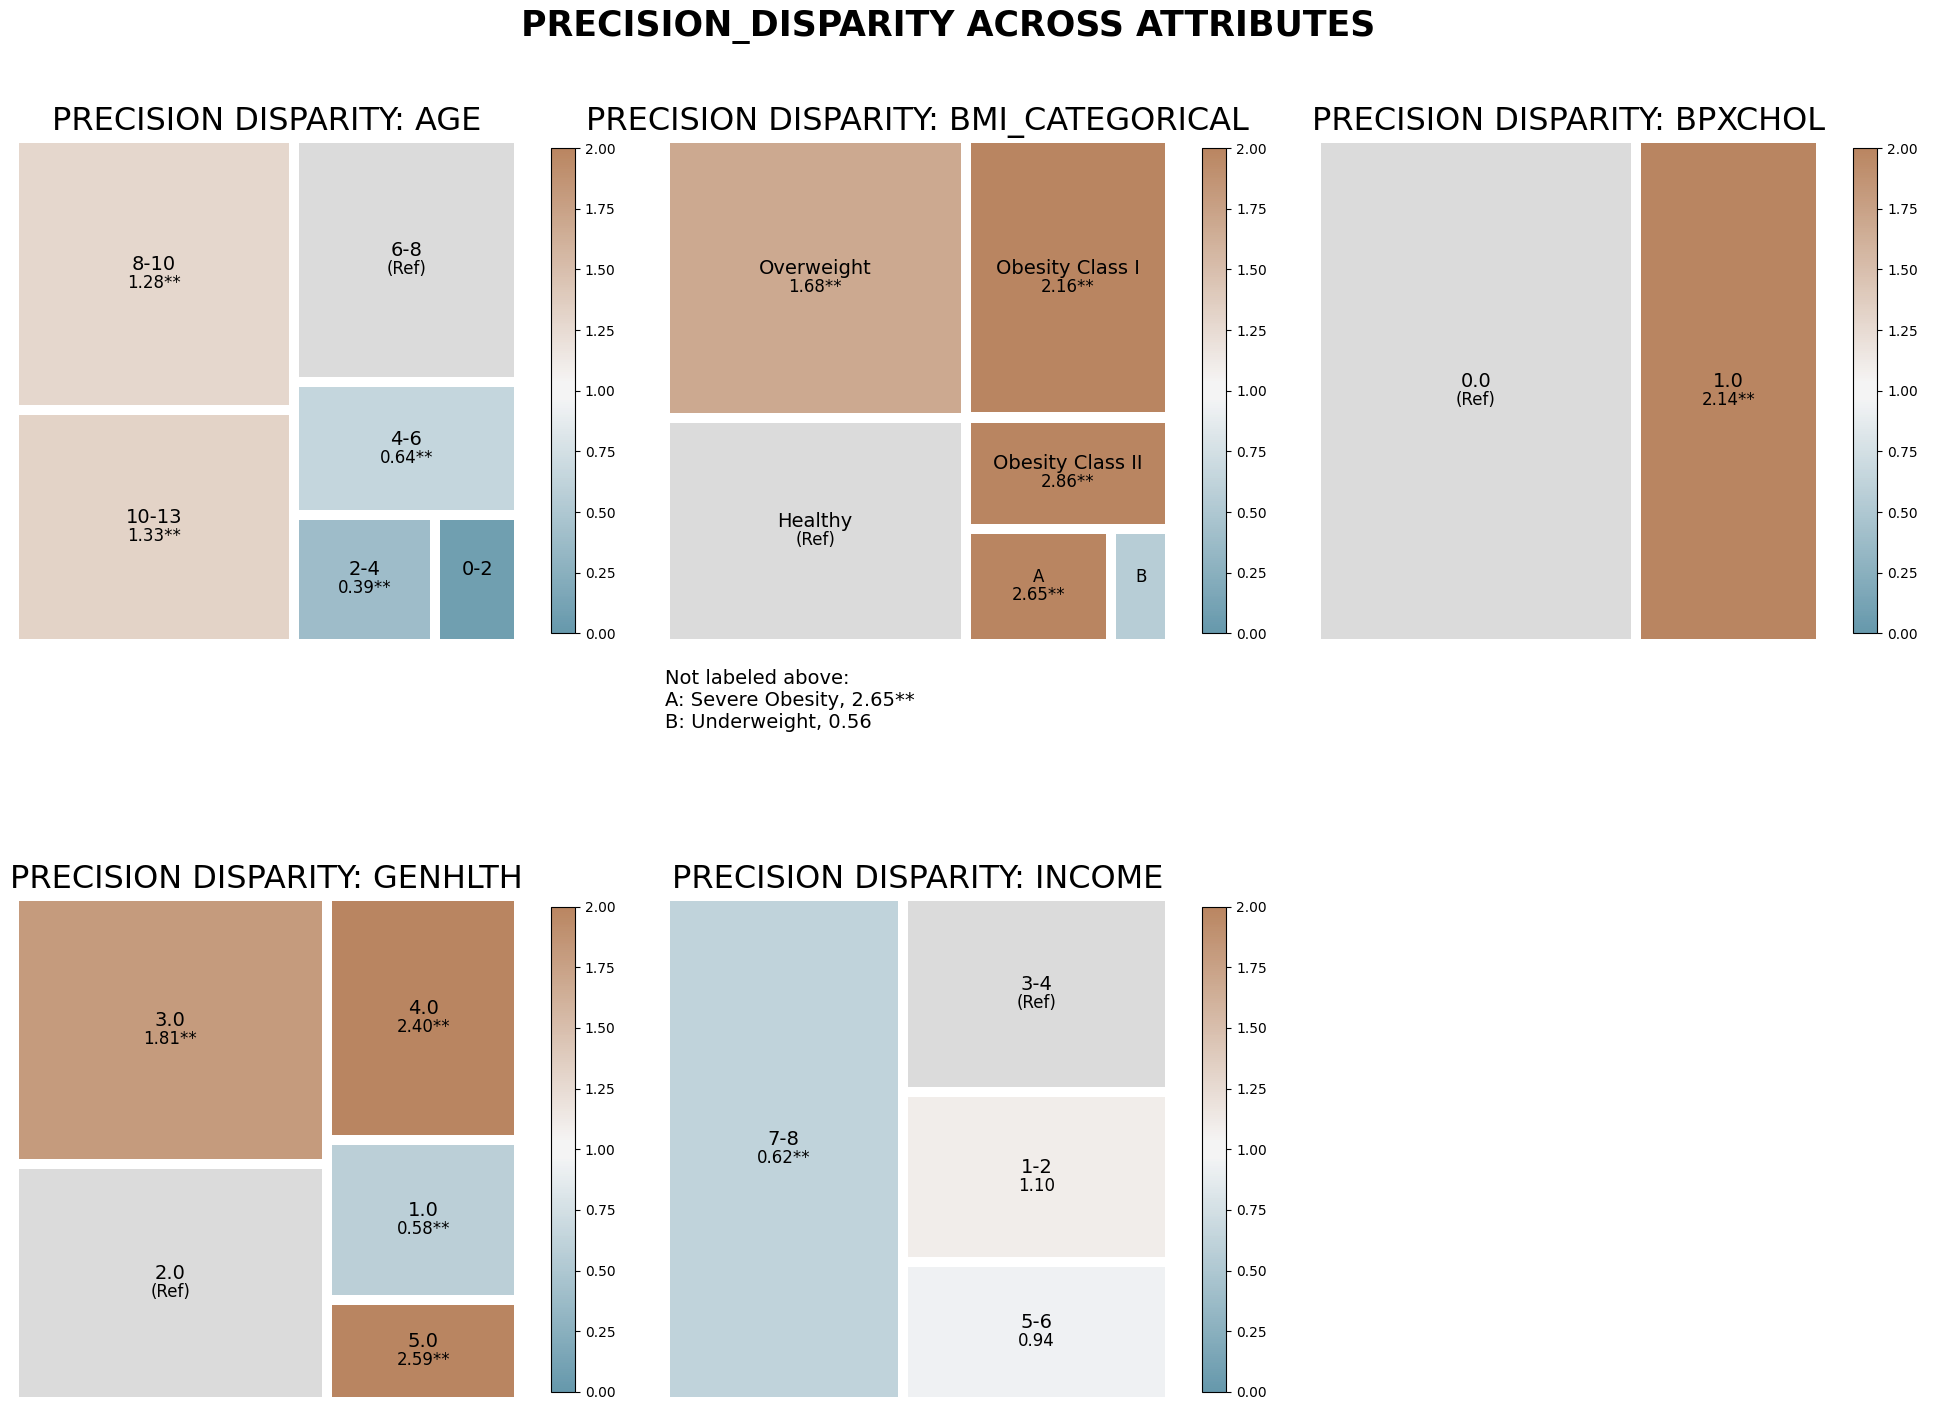

In [137]:
plot = Plot()
j = plot.plot_disparity_all(bias_df, metrics=['precision_disparity'], significance_alpha=0.05)

### Interpretation of Precision Disparities

The precision disparity visualization shows that the model generally has a similar ability to correctly predict positive diabetes cases across most **income and age groups**.

However:

- Precision is **lower for very young patients**, who represent a small portion of the dataset.
- Patients with **high blood pressure and cholesterol** also show lower precision.

A clear pattern appears for **BMI and general health categories**:

- The **higher the BMI**,
- The **worse the general health**

the **higher the precision** of the model.

This indicates that the model is better at predicting true positives (with fewer false positives) for individuals who already have significant health issues.

## True Positive Rate (Sensitivity) Disparities

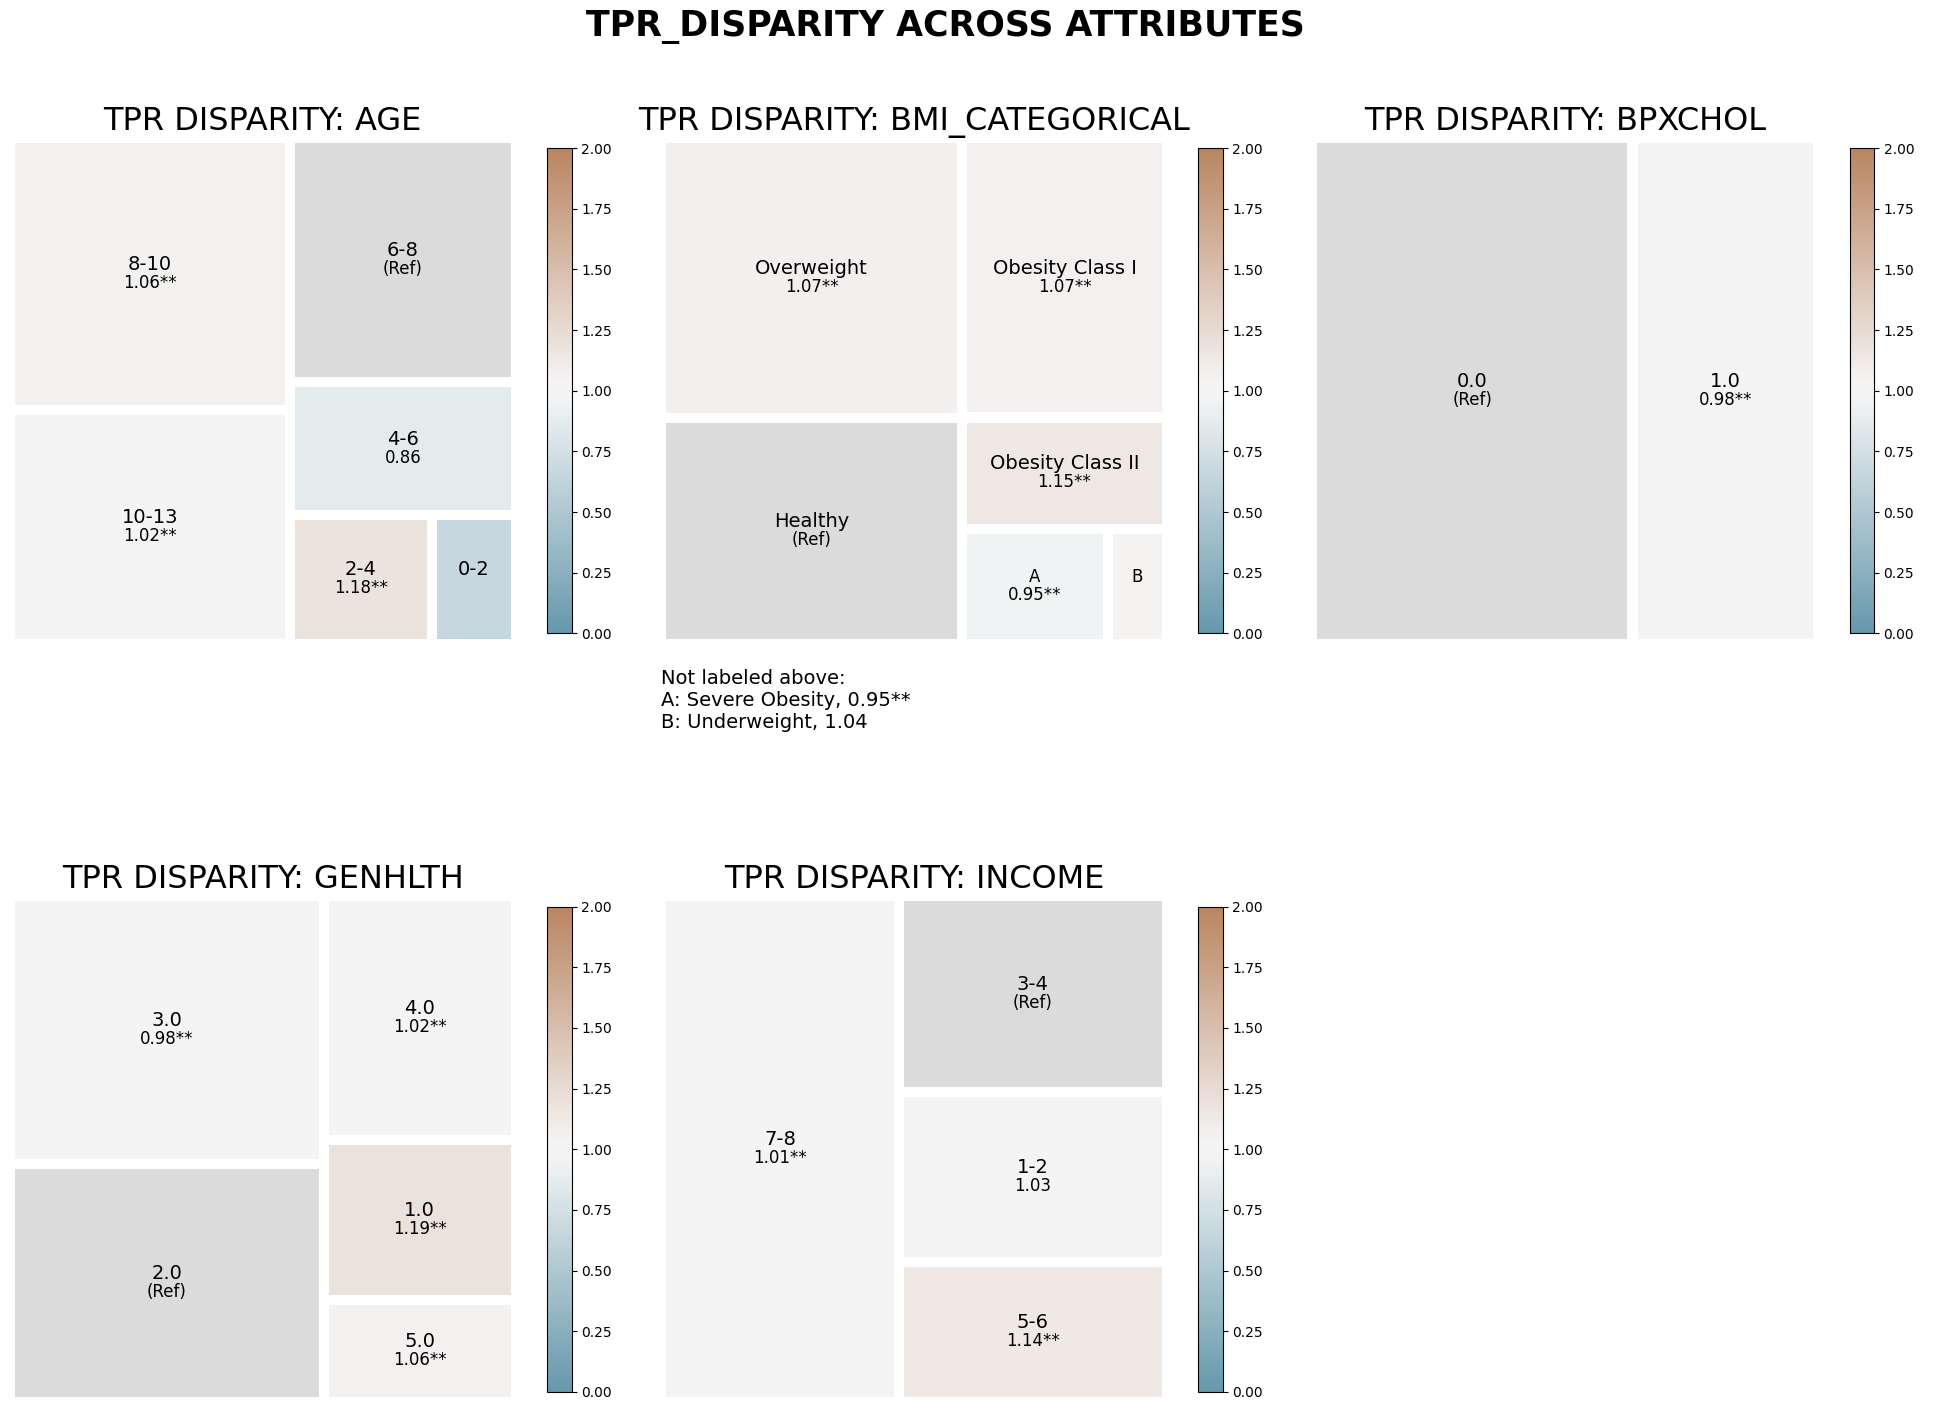

In [138]:
j = plot.plot_disparity_all(bias_df, metrics=['tpr_disparity'], significance_alpha=0.05)

### Interpretation of Sensitivity Disparities

Comparing the precision and sensitivity visualizations shows that **True Positive Rate (TPR) disparities are significantly larger**.

Except for income, every feature presents notable disparities.

Key observations include:

- **Age groups above 6** show higher sensitivity compared to younger groups.
- Patients with **higher BMI**, **higher blood pressure/cholesterol**, or **worse general health** have much higher recall.

For example:

- The sensitivity for **obese patients** is more than **twice as high** as for healthy individuals.

This means the model is better at **identifying diabetic patients with existing health issues** while missing more diabetic cases among healthier individuals.

## Key Findings

Combining the precision and sensitivity analyses highlights several important fairness concerns.
The model appears to discriminate against individuals who are generally healthy, particularly **younger patients**.

For these groups:

- Precision is lower, meaning they are **more likely to be incorrectly predicted as diabetic**.
- Sensitivity is also significantly lower, meaning **actual diabetic cases are more likely to be missed**.

The most significant imbalance appears in **True Positive Rate disparities**, where healthier groups experience substantially lower recall.

One possible explanation for this limitation is the **absence of genetic or hereditary features** in the dataset, which could play a significant role in predicting diabetes for individuals without obvious health risk factors.